# Mean Curvature Flow of a Planar Curve

**Mean curvature flow** is a geometric evolution equation that moves a curve (or surface) in the direction of its curvature vector. For a smooth planar curve $\gamma(\theta, t)$ parametrized over $\theta \in [0, 2\pi)$, the flow reads
$$
\partial_t \gamma = \kappa \, n,
$$
where $\kappa$ is the **signed curvature** and $n$ is the **inward unit normal**.

**Why it matters.** Mean curvature flow has deep connections to:
- the **isoperimetric problem**: a circle (constant curvature) is the unique stationary shape;
- **image processing**: geometric smoothing of contours (Perona–Malik, level-set methods);
- **differential geometry**: the Gage–Hamilton theorem states that any convex curve shrinks to a round point under this flow.

**What we demonstrate.** Starting from a smooth but irregular closed curve with multiple frequency components, we show how the flow progressively regularizes it toward a round circle, which then collapses to a point.

**Discrete approximation.** We represent the curve as a polygon with $n$ equally-spaced angular samples $\{\gamma_i\}_{i=0}^{n-1}$. The curvature vector is approximated by the discrete Laplacian
$$
\kappa_i n_i \approx \frac{\gamma_{i+1} - 2\gamma_i + \gamma_{i-1}}{h^2} \cdot \frac{h^2}{(2\pi/n)^2},
$$
where $h = 2\pi/n$ is the uniform angular spacing. In practice we compute
$$
\kappa_i n_i = \frac{n^2}{(2\pi)^2}\bigl(\gamma_{i+1} - 2\gamma_i + \gamma_{i-1}\bigr),
$$
and integrate with a forward Euler step $\gamma^{(k+1)} = \gamma^{(k)} + \delta t \cdot \kappa n$.

## Setup and initial curve

We define a smooth initial curve in polar form
$$
r(\theta) = 1 + 0.25\cos(3\theta + 0.2) + 0.15\cos(5\theta - 0.5) + 0.10\cos(7\theta + 1.0).
$$
This combines three Fourier modes (frequencies 3, 5, and 7) to produce an irregular but infinitely smooth closed curve — avoiding the non-smooth jumps that arise from functions like $\operatorname{sign}(\sin(\cdot))$. The Cartesian coordinates are
$$
\gamma(\theta) = \bigl(r(\theta)\cos\theta,\; r(\theta)\sin\theta\bigr).
$$

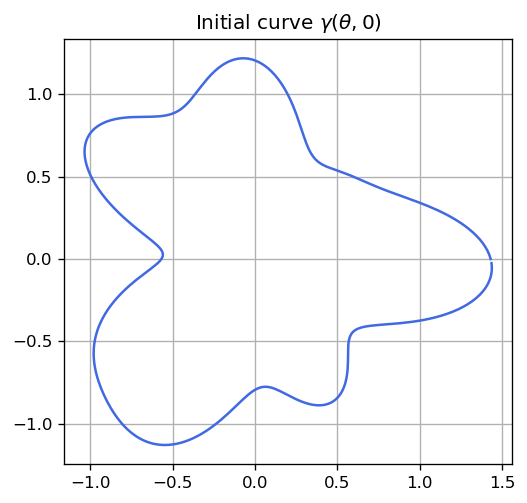

<Figure size 768x576 with 0 Axes>

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUT = Path(".")

n = 360
th = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Smooth multi-frequency initial curve (no sign function)
r = 1.0 + 0.25 * np.cos(3 * th + 0.2) + 0.15 * np.cos(5 * th - 0.5) + 0.10 * np.cos(7 * th + 1.0)
x = r * np.cos(th)
y = r * np.sin(th)
P0 = np.c_[x, y]   # shape (n, 2)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(P0[:, 0], P0[:, 1], lw=1.5, color="royalblue")
ax.set_aspect("equal")
ax.set_title("Initial curve $\\gamma(\\theta, 0)$")
plt.tight_layout()
plt.show()
plt.savefig(OUT / "initial_curve.png", bbox_inches="tight")

## Mean curvature flow evolution

We evolve the curve using forward Euler with a small time step $\delta t = 5 \times 10^{-5}$ for $8000$ steps. The curvature vector is
$$
\kappa_i n_i = \frac{n^2}{(2\pi)^2}\bigl(\gamma_{i+1} - 2\gamma_i + \gamma_{i-1}\bigr),
$$
which uses the constant angular parameterization spacing $h = 2\pi/n$ for stability. After each step we re-center the curve at the origin to avoid drift.

Snapshots are collected at steps $\{0, 1500, 3500, 6000, 7999\}$ to visualize the geometric regularization.

In [2]:
dt = 5e-5
n_steps = 8000
snap_idx = [0, 1500, 3500, 6000, 7999]

P = P0.copy()
snaps = []

# Precompute normalization constant
norm_const = (n / (2 * np.pi)) ** 2   # = n^2 / (2pi)^2

for k in range(n_steps):
    if k in snap_idx:
        snaps.append(P.copy())
    Pp = np.roll(P, -1, axis=0)
    Pm = np.roll(P,  1, axis=0)
    # Discrete curvature vector with uniform-angle normalization
    curv_vec = (Pp - 2.0 * P + Pm) * norm_const
    P = P + dt * curv_vec
    # Re-center to remove translation drift
    P -= P.mean(axis=0, keepdims=True)

print(f"Evolution done. {len(snaps)} snapshots collected.")

Evolution done. 5 snapshots collected.


## Visualization: curve snapshots

The five panels below show the curve at increasing time steps. The irregular oscillations are progressively smoothed and the curve asymptotically approaches a circle before collapsing to a point (Gage–Hamilton theorem). Note the steady decrease in amplitude and the gradual loss of high-frequency details.

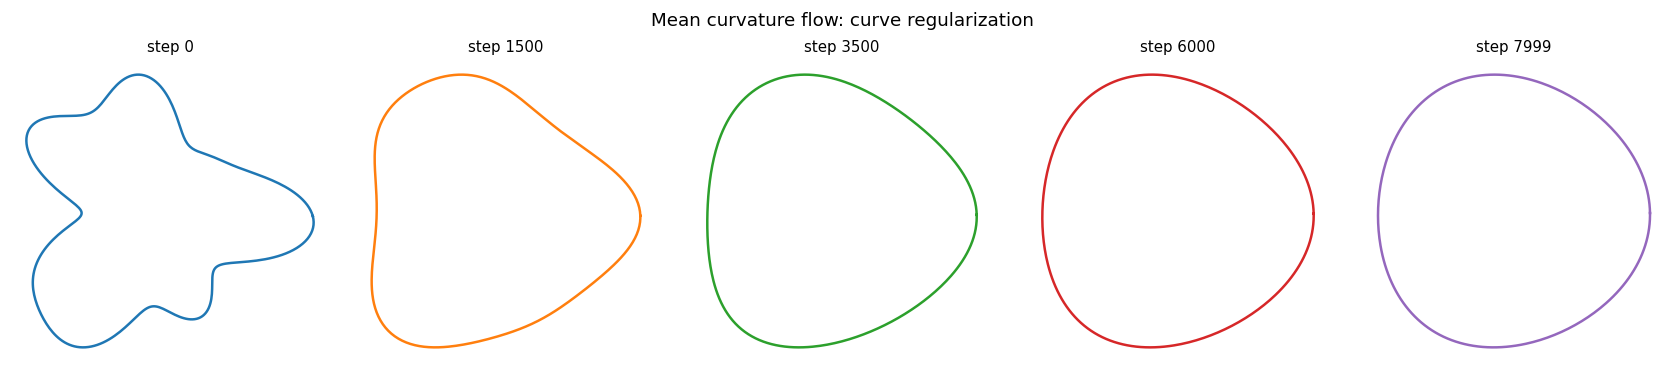

In [3]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(1, 5, figsize=(14, 3.0), constrained_layout=True)
for ax, S, k, col in zip(axes, snaps, snap_idx, colors):
    # Close the curve for plotting
    Sc = np.vstack([S, S[:1]])
    ax.plot(Sc[:, 0], Sc[:, 1], lw=1.5, color=col)
    ax.set_aspect("equal")
    ax.set_title(f"step {k}", fontsize=9)
    ax.axis("off")

fig.suptitle("Mean curvature flow: curve regularization", fontsize=11)
plt.show()
fig.savefig(OUT / "snippet.png", bbox_inches="tight")

## Static snapshot (for automated export)

The cell below saves the same figure as `snippet.png` under the notebook folder. It is guarded by `STATIC_SNAPSHOT` so it can be skipped in interactive sessions where the figure above is already rendered.

In [4]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    fig2, axes2 = plt.subplots(1, 5, figsize=(14, 3.0), constrained_layout=True)
    for ax, S, k, col in zip(axes2, snaps, snap_idx, colors):
        Sc = np.vstack([S, S[:1]])
        ax.plot(Sc[:, 0], Sc[:, 1], lw=1.5, color=col)
        ax.set_aspect("equal")
        ax.set_title(f"step {k}", fontsize=9)
        ax.axis("off")
    fig2.suptitle("Mean curvature flow: curve regularization", fontsize=11)
    fig2.savefig(OUT / "snippet.png", bbox_inches="tight")
    plt.close(fig2)
    print(f"Snippet saved to {OUT / 'snippet.png'}")

Snippet saved to snippet.png


## Takeaways

- **Geometric regularization:** Mean curvature flow smooths irregularities by diffusing the curvature along the curve; high-frequency perturbations decay fastest.
- **Smooth initial data matters:** Using a smooth initial curve (sum of cosines) avoids spurious oscillations that arise from non-smooth functions like $\operatorname{sign}$, which would create instabilities in the discrete curvature estimate.
- **Stability via uniform parameterization:** Normalizing by $(n/(2\pi))^2$ rather than the local arc-length squared prevents overflow when the curve becomes nearly degenerate.
- **Gage–Hamilton theorem:** Any smooth embedded convex curve converges to a round point; the flow is the gradient flow of the length functional.

## Bibliographical Resources

- M. E. Gage and R. S. Hamilton, "The heat equation shrinking convex plane curves", *J. Differential Geometry*, 23(1):69–96, 1986.
- M. A. Grayson, "The heat equation shrinks embedded plane curves to round points", *J. Differential Geometry*, 26(2):285–314, 1987.
- G. Sapiro, *Geometric Partial Differential Equations and Image Analysis*, Cambridge University Press, 2001.
- S. Osher and R. Fedkiw, *Level Set Methods and Dynamic Implicit Surfaces*, Springer, 2003.